## Housing Dataset

## Wine Recognition Dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# Load the dataset
wine = load_wine(as_frame=True)

df = wine.frame

# Display the first 5 rows
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [10]:
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 142
Test samples: 36


In [11]:
# Create Logistic Regression model
log_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

# Train the model
log_model.fit(X_train, y_train)

# Make predictions
log_train_pred = log_model.predict(X_train)
log_test_pred = log_model.predict(X_test)

# Calculate accuracy
log_train_acc = accuracy_score(y_train, log_train_pred)
log_test_acc = accuracy_score(y_test, log_test_pred)

print("Logistic Regression")
print("Training Accuracy:", log_train_acc)
print("Test Accuracy:", log_test_acc)

Logistic Regression
Training Accuracy: 1.0
Test Accuracy: 0.9722222222222222


/Users/najaandriamumtaz/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/najaandriamumtaz/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: overflow encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/najaandriamumtaz/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: invalid value encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights


In [12]:
depths = [1, 2, 3, 5, 10, 15]

results = []

# Add Logistic Regression results
results.append({
    "Model": "Logistic Regression",
    "Training Accuracy": log_train_acc,
    "Test Accuracy": log_test_acc
})

# Train Decision Trees with different depths
for depth in depths:

    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    # Train the model
    tree.fit(X_train, y_train)

    # Make predictions
    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    # Calculate accuracy
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    # Store results
    results.append({
        "Model": f"Decision Tree (depth={depth})",
        "Training Accuracy": train_acc,
        "Test Accuracy": test_acc
    })

# Display results
results_df = pd.DataFrame(results)

results_df

,Model,Training Accuracy,Test Accuracy
0,Logistic Regression,1.000000,0.972222
1,Decision Tree (depth=1),0.661972,0.583333
2,Decision Tree (depth=2),0.936620,0.861111
3,Decision Tree (depth=3),0.992958,0.944444
4,Decision Tree (depth=5),1.000000,0.944444
5,Decision Tree (depth=10),1.000000,0.944444
6,Decision Tree (depth=15),1.000000,0.944444


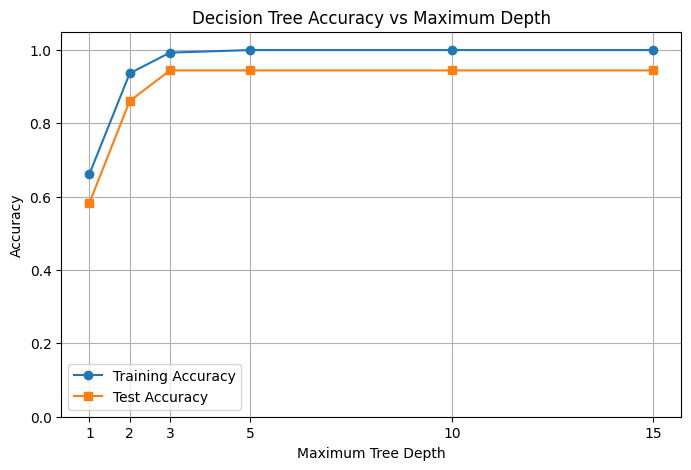

In [13]:
tree_results = results_df.iloc[1:]

plt.figure(figsize=(8, 5))

plt.plot(
    depths,
    tree_results["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depths,
    tree_results["Test Accuracy"],
    marker="s",
    label="Test Accuracy"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy vs Maximum Depth")

plt.xticks(depths)
plt.ylim(0, 1.05)

plt.legend()
plt.grid(True)

plt.show()

## Questions